In [1]:
import sys
sys.path.insert(0, '/home/stargix/Desktop/uni/aprens/Lab8/APRNS-Lab-8/pytorch-generative')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from pytorch_generative import models
from tqdm import tqdm
from scipy import stats, fft
from scipy.spatial.distance import euclidean, cosine
from scipy.stats import wasserstein_distance, ks_2samp, entropy
from scipy.special import kl_div
from time import time
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

init_time = time()

2025-12-09 11:31:04.053819: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 11:31:04.121343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda


In [3]:
from apafib import load_MITBIH

df_mitbih = load_MITBIH()
df_normal = df_mitbih[df_mitbih['target'] == 'Normal'].copy()

signal_columns = [col for col in df_normal.columns if col != 'target']
X_normal_original = df_normal[signal_columns].values

# Añadir padding
zeros_padding = np.zeros((X_normal_original.shape[0], 2))
X_normal = np.concatenate([X_normal_original, zeros_padding], axis=1)

print(f"Dataset: {len(df_normal)} señales normales, longitud: {X_normal.shape[1]}")

Dataset: 7263 señales normales, longitud: 96


In [4]:
class ECGPreprocessor:    
    def __init__(self, window_size, vocab_size, overlap=0):
        self.window_size = window_size
        self.vocab_size = vocab_size
        self.overlap = overlap
        self.gmm = None
        self.centroids = None
        
    def create_windows(self, signals):
        windows = []
        stride = self.window_size - self.overlap
        for signal in signals:
            n_windows = (len(signal) - self.window_size) // stride + 1
            for i in range(n_windows):
                start = i * stride
                end = start + self.window_size
                if end <= len(signal):
                    windows.append(signal[start:end])
        return np.array(windows)
    
    def fit_gmm(self, signals):
        windows = self.create_windows(signals)
        all_values = windows.flatten().reshape(-1, 1)
        self.gmm = GaussianMixture(n_components=self.vocab_size, covariance_type='full', 
                                    random_state=42, max_iter=100)
        self.gmm.fit(all_values)
        self.centroids = self.gmm.means_
        
    def discretize_signal(self, signal):        
        signal_reshaped = signal.reshape(-1, 1)
        labels = self.gmm.predict(signal_reshaped)
        return labels
    
    def discretize_windows(self, windows):
        return np.array([self.discretize_signal(window) for window in windows])
    
    def reconstruct_signal(self, discrete_signal):        
        return self.centroids[discrete_signal]

def split_dataset(X, train_ratio=0.5, val_ratio=0.25, test_ratio=0.25):
    X_train, X_temp = train_test_split(X, test_size=(val_ratio + test_ratio), random_state=42)
    val_fraction = val_ratio / (val_ratio + test_ratio)
    X_val, X_test = train_test_split(X_temp, test_size=(1 - val_fraction), random_state=42)
    return X_train, X_val, X_test

Train: 19368 ventanas | Val: 9680 | Test: 9688


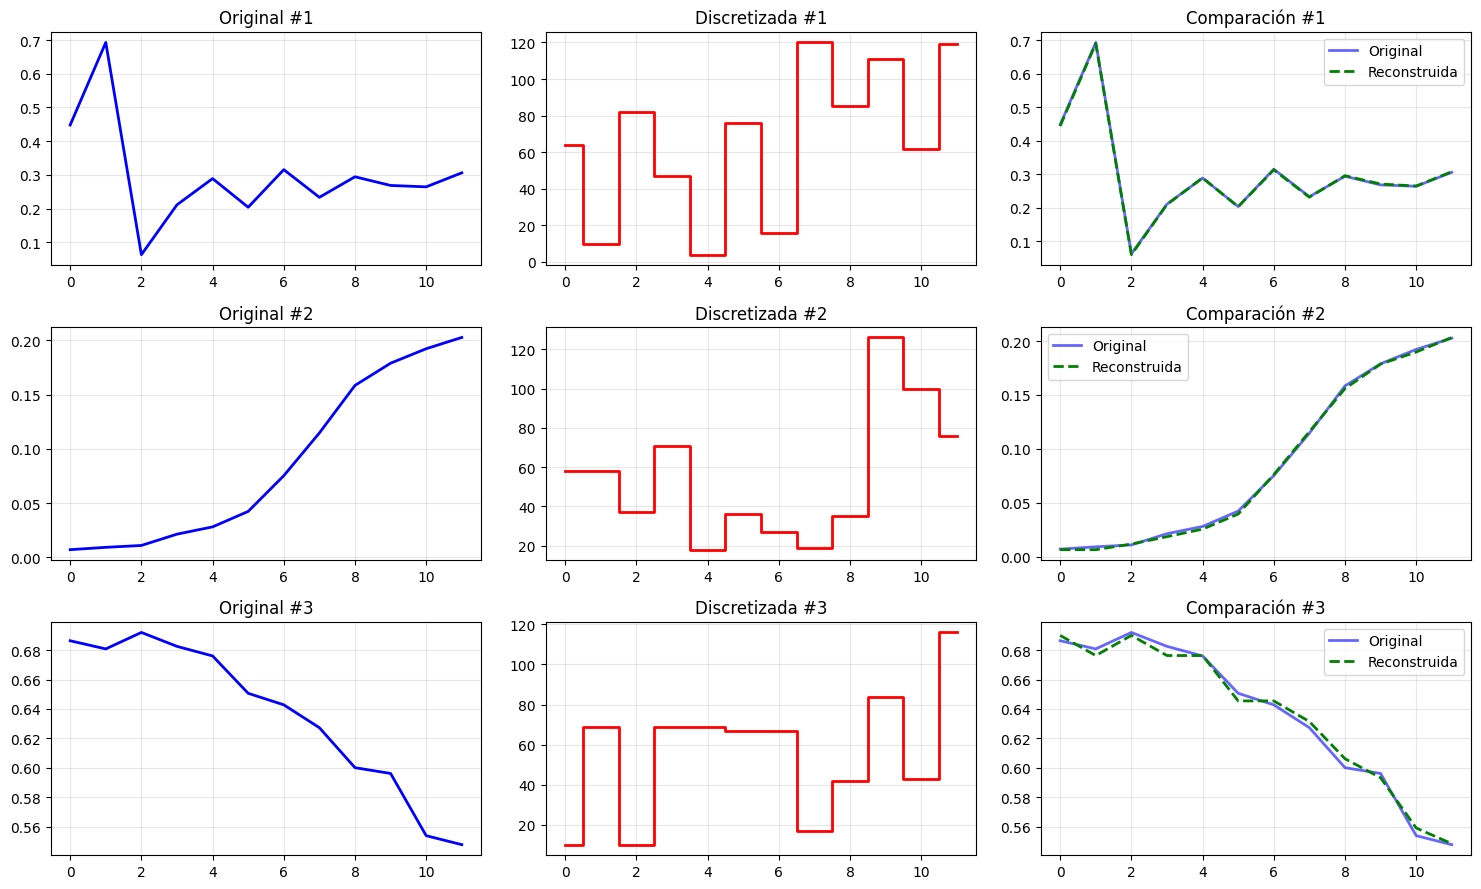

In [5]:
WINDOW_SIZE = 12
VOCAB_SIZE = 128

X_for_gmm, X_remaining = train_test_split(X_normal, test_size=2/3, random_state=42)
preprocessor = ECGPreprocessor(window_size=WINDOW_SIZE, vocab_size=VOCAB_SIZE)
preprocessor.fit_gmm(X_for_gmm)

X_train, X_val, X_test = split_dataset(X_remaining, 0.5, 0.25, 0.25)
windows_train = preprocessor.create_windows(X_train)
windows_val = preprocessor.create_windows(X_val)
windows_test = preprocessor.create_windows(X_test)

discrete_train = preprocessor.discretize_windows(windows_train)
discrete_val = preprocessor.discretize_windows(windows_val)
discrete_test = preprocessor.discretize_windows(windows_test)

print(f"Train: {len(windows_train)} ventanas | Val: {len(windows_val)} | Test: {len(windows_test)}")

n_examples = 3
fig, axes = plt.subplots(n_examples, 3, figsize=(15, 3*n_examples))
for i in range(n_examples):
    sample_idx = i * (len(windows_train) // n_examples + 1)
    original_window = windows_train[sample_idx]
    discrete_window = discrete_train[sample_idx]
    reconstructed_window = preprocessor.reconstruct_signal(discrete_window)
    
    axes[i, 0].plot(original_window, 'b-', linewidth=2)
    axes[i, 0].set_title(f'Original #{i+1}')
    axes[i, 0].grid(True, alpha=0.3)
    
    axes[i, 1].step(range(len(discrete_window)), discrete_window, 'r-', where='mid', linewidth=2)
    axes[i, 1].set_title(f'Discretizada #{i+1}')
    axes[i, 1].grid(True, alpha=0.3)
    
    axes[i, 2].plot(original_window, 'b-', alpha=0.6, linewidth=2, label='Original')
    axes[i, 2].plot(reconstructed_window, 'g--', linewidth=2, label='Reconstruida')
    axes[i, 2].set_title(f'Comparación #{i+1}')
    axes[i, 2].grid(True, alpha=0.3)
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

## Dataset y DataLoader para Entrenamiento

In [6]:
class ECGWindowDataset(Dataset):
    def __init__(self, discrete_windows, vocab_size):
        self.discrete_windows = torch.LongTensor(discrete_windows)
        self.vocab_size = vocab_size
        
    def __len__(self):
        return len(self.discrete_windows)
    
    def __getitem__(self, idx):
        discrete_window = self.discrete_windows[idx]
        one_hot = F.one_hot(discrete_window, num_classes=self.vocab_size)
        return one_hot.reshape(-1).float()

BATCH_SIZE = 128

train_dataset = ECGWindowDataset(discrete_train, VOCAB_SIZE)
val_dataset = ECGWindowDataset(discrete_val, VOCAB_SIZE)
test_dataset = ECGWindowDataset(discrete_test, VOCAB_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches - Train: 152 | Val: 76 | Test: 76


In [7]:
def loss_fn(x, preds):
    batch_size = x.shape[0]
    x, preds = x.view((batch_size, -1)), preds.view((batch_size, -1))
    loss = F.binary_cross_entropy_with_logits(preds, x, reduction="none")
    return loss.sum(dim=1).mean()

def train_loop(model, optimizer, scheduler, loss_fn, dataloader, epochs):
    hist_loss = []
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # bucle para todos los epochs
        running_loss = 0.0
        for i, data in enumerate(dataloader):
            # obtenemos los datos y los subimos a la GPU
            inputs = data.to(device)

            # Reiniciamos los gradientes
            optimizer.zero_grad()

            # Aplicamos los datos al modelo
            outputs = model(inputs)

            # Calculamos la perdida
            loss = loss_fn(inputs, outputs)

            # Hacemos el paso hacia atras
            loss.backward()
            optimizer.step()

            # Vamos guardando la perdida
            running_loss += loss.item()

        if scheduler is not None:
            scheduler.step()
            lr = f'lr: {scheduler.get_last_lr()[0]:.4E}'
        else:
            lr = ''

        hist_loss.append(running_loss / i)
        pbar.set_description(f'loss: {running_loss / i:3.4f}:{lr}')

    return hist_loss

In [8]:
input_dim = WINDOW_SIZE * VOCAB_SIZE
hidden_dims = [512]
n_masks = 1

made_model = models.MADE(input_dim=input_dim, hidden_dims=hidden_dims, n_masks=n_masks)
made_model.to(device)

optimizer = optim.AdamW(made_model.parameters(), lr=3e-3, weight_decay=2e-6, 
                        betas=(0.9, 0.999), eps=1e-8)
scheduler = lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lambda _: 0.99999)

print(f"Modelo MADE configurado: {sum(p.numel() for p in made_model.parameters()):,} parámetros")

Modelo MADE configurado: 1,574,912 parámetros


In [9]:
EPOCHS = 800
train_losses = train_loop(
    model=made_model,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=loss_fn,
    dataloader=train_loader,
    epochs=EPOCHS
)

print(f"\nEntrenamiento completado - Train loss final: {train_losses[-1]:.4f}")

loss: 10.2345:lr: 2.9761E-03: 100%|██████████| 800/800 [19:56<00:00,  1.50s/it]


Entrenamiento completado - Train loss final: 10.2345


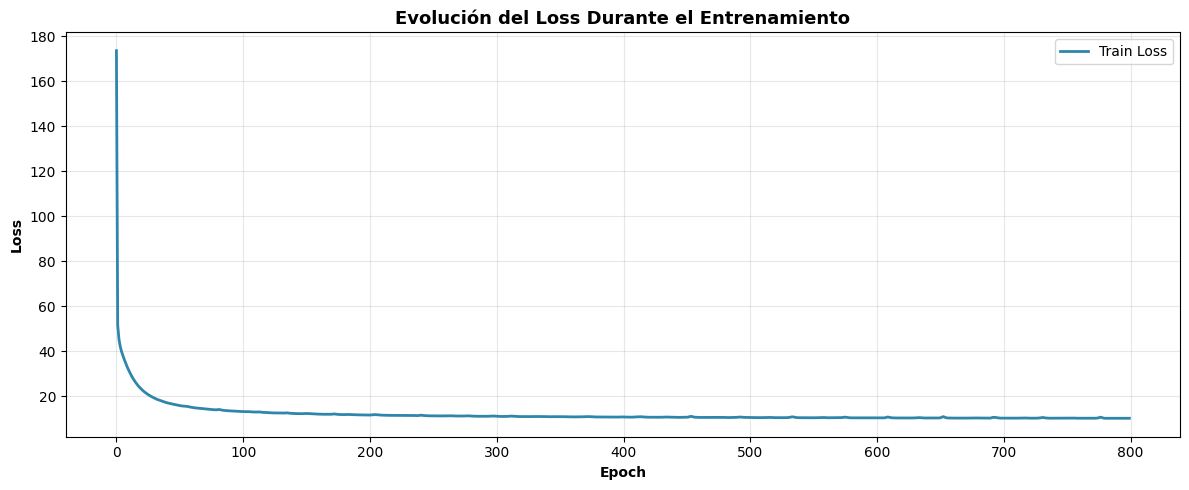

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(train_losses, linewidth=2, label='Train Loss', color='#2E86AB')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Loss', fontweight='bold')
ax.set_title('Evolución del Loss Durante el Entrenamiento', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Generación de Muestras Sintéticas

In [11]:
def generate_samples_made(model, n_samples, window_size, vocab_size, device):
    model.eval()
    generated_discrete = []
    
    with torch.no_grad():
        for _ in range(n_samples):
            sample = torch.zeros(window_size, dtype=torch.long).to(device)
            
            for pos in range(window_size):
                one_hot = F.one_hot(sample, num_classes=vocab_size)
                one_hot_flat = one_hot.reshape(-1).float().unsqueeze(0)
                logits = model(one_hot_flat)
                logits_reshaped = logits.reshape(window_size, vocab_size)
                pos_logits = logits_reshaped[pos]
                probs = F.softmax(pos_logits, dim=-1)
                sample[pos] = torch.multinomial(probs, 1).item()
            
            generated_discrete.append(sample.cpu().numpy())
    
    return np.array(generated_discrete)

n_generated = 12
generated_discrete = generate_samples_made(made_model, n_generated, WINDOW_SIZE, VOCAB_SIZE, device)

generated_signals = []
for discrete_seq in generated_discrete:
    reconstructed = preprocessor.reconstruct_signal(discrete_seq)
    generated_signals.append(reconstructed.flatten())

generated_signals = np.array(generated_signals)

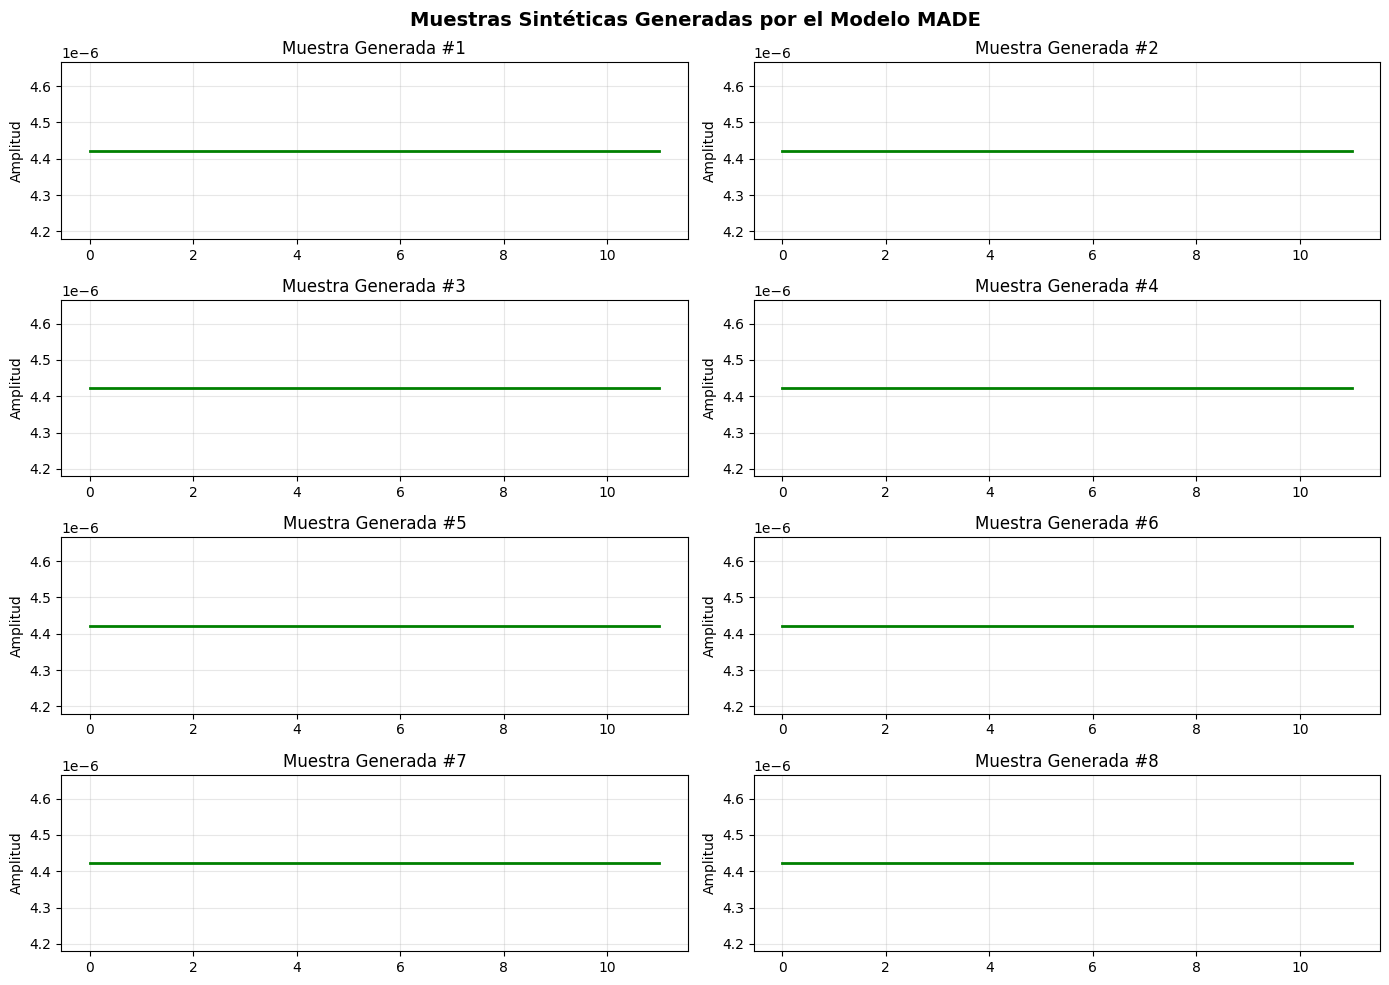

In [12]:
n_to_show = min(8, n_generated)
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(n_to_show):
    axes[i].plot(generated_signals[i], 'g-', linewidth=2)
    axes[i].set_title(f'Muestra Generada #{i+1}')
    axes[i].set_ylabel('Amplitud')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Muestras Sintéticas Generadas por el Modelo MADE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Análisis de Similitud: Generadas vs Reales

Comparación Estadística:
Métrica                    Generadas          Reales      Diferencia
Media                         0.0000          0.1121          0.1121
Desv. Estándar                0.0000          0.1724          0.1724
Mediana                       0.0000          0.0395          0.0395
Mínimo                        0.0000         -0.0264          0.0264
Máximo                        0.0000          0.9764          0.9764


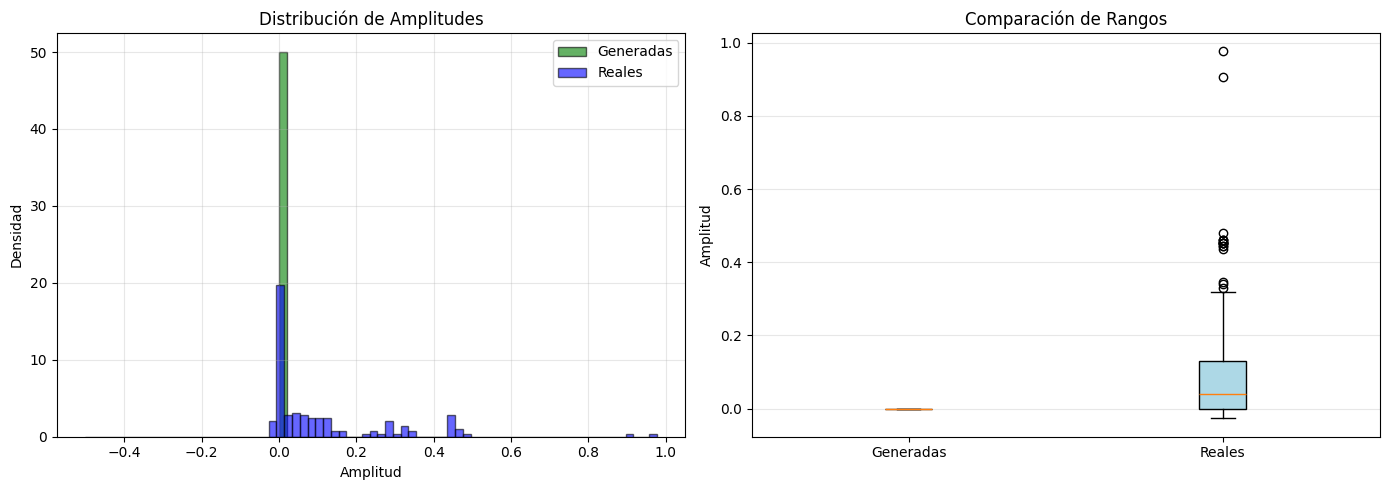

In [13]:
n_samples_compare = len(generated_signals)
random_real_signals = []
for _ in range(n_samples_compare):
    idx = np.random.randint(0, len(windows_train))
    real_signal = preprocessor.reconstruct_signal(discrete_train[idx]).flatten()
    random_real_signals.append(real_signal)
random_real_signals = np.array(random_real_signals)

stats_metrics = {
    'Media': (np.mean(generated_signals), np.mean(random_real_signals)),
    'Desv. Estándar': (np.std(generated_signals), np.std(random_real_signals)),
    'Mediana': (np.median(generated_signals), np.median(random_real_signals)),
    'Mínimo': (np.min(generated_signals), np.min(random_real_signals)),
    'Máximo': (np.max(generated_signals), np.max(random_real_signals)),
}

print("Comparación Estadística:")
print(f"{'Métrica':<20} {'Generadas':>15} {'Reales':>15} {'Diferencia':>15}")
for metric, (gen_val, real_val) in stats_metrics.items():
    diff = abs(gen_val - real_val)
    print(f"{metric:<20} {gen_val:>15.4f} {real_val:>15.4f} {diff:>15.4f}")

# Distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(generated_signals.flatten(), bins=50, alpha=0.6, color='green', 
             label='Generadas', density=True, edgecolor='black')
axes[0].hist(random_real_signals.flatten(), bins=50, alpha=0.6, color='blue', 
             label='Reales', density=True, edgecolor='black')
axes[0].set_xlabel('Amplitud')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Amplitudes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

box_data = [generated_signals.flatten(), random_real_signals.flatten()]
bp = axes[1].boxplot(box_data, labels=['Generadas', 'Reales'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightblue')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Comparación de Rangos')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Detección de Anomalías y Verosimilitud

In [14]:
def calculate_nll(model, samp):
    epsilon = 1e-15
    snll = 0.0
    for i in range(samp.shape[0]):
        mu = torch.sigmoid(model(samp[i]).detach())
        snll += ((samp[i] * torch.log(mu+epsilon)) + ((1-samp[i]) * torch.log(1-mu+epsilon))).sum()
    return -snll.cpu()

train_nll = calculate_nll(made_model, train_loader, device)
val_nll = calculate_nll(made_model, val_loader, device)
test_nll = calculate_nll(made_model, test_loader, device)

print(f"Verosimilitud (NLL):")
print(f"  Train: {train_nll:.4f}")
print(f"  Val:   {val_nll:.4f}")
print(f"  Test:  {test_nll:.4f}")

sets = ['Train', 'Val', 'Test']
nlls = [train_nll, val_nll, test_nll]

plt.figure(figsize=(10, 6))
bars = plt.bar(sets, nlls, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8, edgecolor='black', linewidth=2)
plt.ylabel('NLL Promedio')
plt.title('Log-Verosimilitud Negativa por Conjunto')
plt.grid(True, alpha=0.3, axis='y')

for bar, nll in zip(bars, nlls):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{nll:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

TypeError: calculate_nll() takes 2 positional arguments but 3 were given

## Comparación con Otras Clases (Detección de Anomalías)

In [ ]:
all_classes = df_mitbih['target'].unique()
classes = [c for c in all_classes if c != 'Normal']
n_samples_per_class = 20
class_nlls = {}

for class_name in classes:
    class_data = df_mitbih[df_mitbih['target'] == class_name]
    if len(class_data) == 0:
        continue
    
    class_sample = class_data.sample(n=min(n_samples_per_class, len(class_data)), random_state=42)
    X_class = class_sample[signal_columns].values
    
    zeros_padding_class = np.zeros((X_class.shape[0], 2))
    X_class_padded = np.concatenate([X_class, zeros_padding_class], axis=1)
    
    windows_class = preprocessor.create_windows(X_class_padded)
    discrete_class = preprocessor.discretize_windows(windows_class)
    
    class_dataset = ECGWindowDataset(discrete_class, VOCAB_SIZE)
    class_loader = DataLoader(class_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    nll_class = calculate_nll(made_model, class_loader, device)
    class_nlls[class_name] = nll_class

print(f"\nComparación de NLL:")
print(f"  Normal (Test): {test_nll:.4f}")
for class_name, nll in class_nlls.items():
    diff = nll - test_nll
    ratio = nll / test_nll
    print(f"  {class_name:15s} {nll:8.4f}  (+{diff:6.2f}, {ratio:.2f}x)")


Comparación de NLL:
  Normal (Test): 21.1647
  ArrS             23.0862  (+  1.92, 1.09x)
  ArrQ             24.4624  (+  3.30, 1.16x)
  ArrV             23.4986  (+  2.33, 1.11x)
  ArrF             17.1883  (+ -3.98, 0.81x)


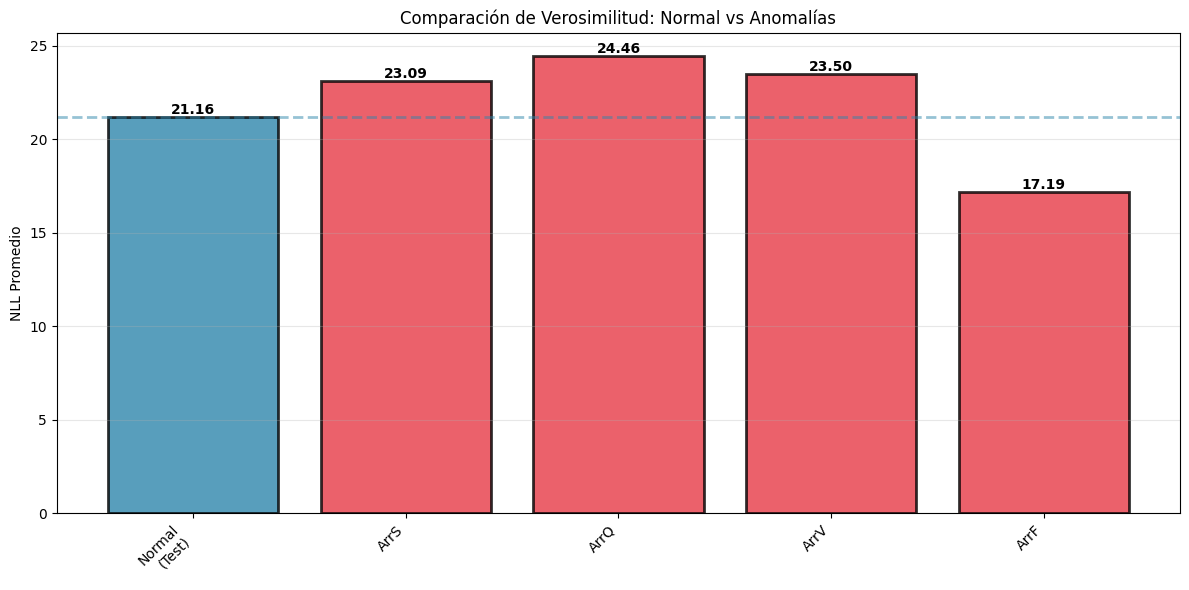

In [ ]:
all_class_names = ['Normal\n(Test)'] + list(class_nlls.keys())
all_nlls = [test_nll] + list(class_nlls.values())

fig, ax = plt.subplots(figsize=(12, 6))

colors_list = ['#2E86AB'] + ['#E63946'] * len(class_nlls)
bars = ax.bar(range(len(all_class_names)), all_nlls, color=colors_list, alpha=0.8, 
              edgecolor='black', linewidth=2)

ax.set_xticks(range(len(all_class_names)))
ax.set_xticklabels(all_class_names, rotation=45, ha='right')
ax.set_ylabel('NLL Promedio')
ax.set_title('Comparación de Verosimilitud: Normal vs Anomalías')
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, nll) in enumerate(zip(bars, all_nlls)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{nll:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=test_nll, color='#2E86AB', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

#se suposa que tots els nll de les anomalies haurien de ser més grans que normal pero no aconsegueixo que es posi per sota del ArrF. 

Tamaño del dataset:
  Normal: 7263 señales
  ArrF:   60 señales

ESTADÍSTICAS COMPARATIVAS
Métrica                       Normal            ArrF      Diferencia
----------------------------------------------------------------------
Media                         0.1586          0.1138          0.0448
Desv. Std                     0.2180          0.2090          0.0091
Mediana                       0.0672          0.0004          0.0668
Mínimo                       -0.1068         -0.1013          0.0055
Máximo                        1.0682          0.9891          0.0791
Rango                         1.1750          1.0904          0.0846
Skewness                      1.7159          2.3329          0.6171
Kurtosis                      2.7412          5.1709          2.4297


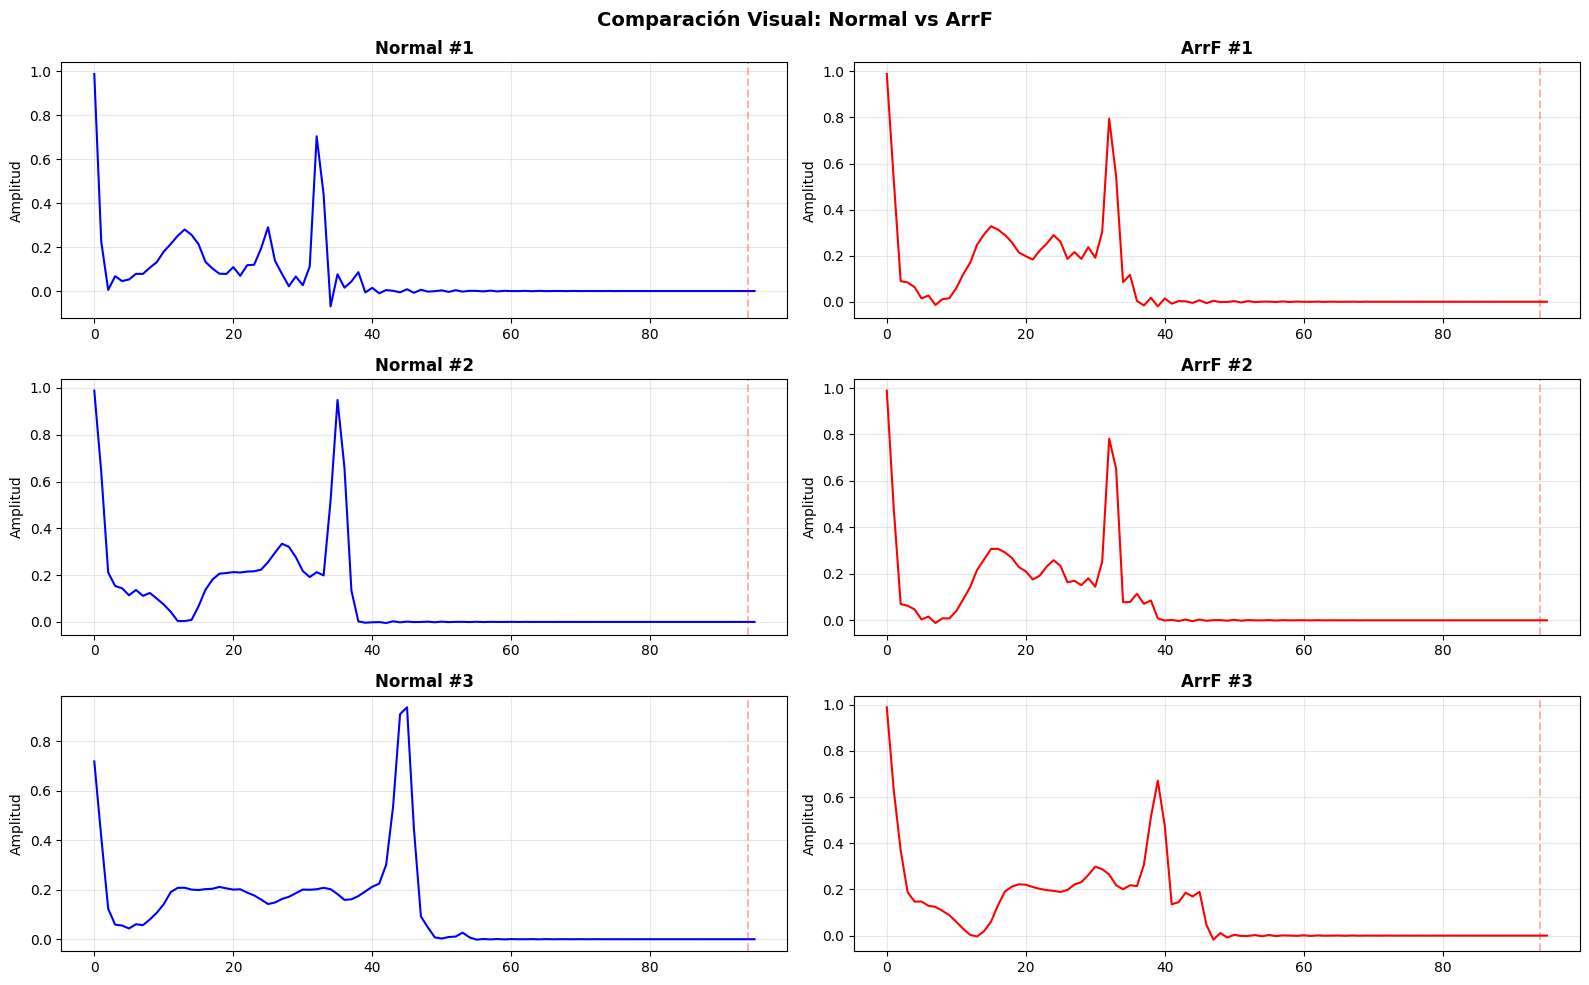

In [ ]:
arrF_data = df_mitbih[df_mitbih['target'] == 'ArrF']
X_arrF = arrF_data[signal_columns].values

zeros_padding_arrF = np.zeros((X_arrF.shape[0], 2))
X_arrF_padded = np.concatenate([X_arrF, zeros_padding_arrF], axis=1)

print(f"Tamaño del dataset:")
print(f"  Normal: {len(df_normal)} señales")
print(f"  ArrF:   {len(arrF_data)} señales")

print(f"\n{'='*70}")
print("ESTADÍSTICAS COMPARATIVAS")
print(f"{'='*70}")
print(f"{'Métrica':<20} {'Normal':>15} {'ArrF':>15} {'Diferencia':>15}")
print("-"*70)

stats_comparison = {
    'Media': (X_normal.mean(), X_arrF_padded.mean()),
    'Desv. Std': (X_normal.std(), X_arrF_padded.std()),
    'Mediana': (np.median(X_normal), np.median(X_arrF_padded)),
    'Mínimo': (X_normal.min(), X_arrF_padded.min()),
    'Máximo': (X_normal.max(), X_arrF_padded.max()),
    'Rango': (X_normal.ptp(), X_arrF_padded.ptp()),
    'Skewness': (stats.skew(X_normal.flatten()), stats.skew(X_arrF_padded.flatten())),
    'Kurtosis': (stats.kurtosis(X_normal.flatten()), stats.kurtosis(X_arrF_padded.flatten())),
}

for metric, (normal_val, arrF_val) in stats_comparison.items():
    diff = abs(normal_val - arrF_val)
    print(f"{metric:<20} {normal_val:>15.4f} {arrF_val:>15.4f} {diff:>15.4f}")

# Visualización de señales
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i in range(3):
    # Normal
    axes[i, 0].plot(X_normal[i], 'b-', linewidth=1.5)
    axes[i, 0].set_title(f'Normal #{i+1}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Amplitud')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axvline(x=94, color='red', linestyle='--', alpha=0.3)
    
    # ArrF
    axes[i, 1].plot(X_arrF_padded[i], 'r-', linewidth=1.5)
    axes[i, 1].set_title(f'ArrF #{i+1}', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('Amplitud')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].axvline(x=94, color='red', linestyle='--', alpha=0.3)

plt.suptitle('Comparación Visual: Normal vs ArrF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


ANÁLISIS DE COMPLEJIDAD (Entropía de Shannon)
  Entropía Normal: 2.7017 bits
  Entropía ArrF:   2.0689 bits
  Diferencia:      0.6328 bits

  ✓ ArrF tiene MENOR entropía → Más predecible
    Las señales ArrF tienen patrones más repetitivos/regulares


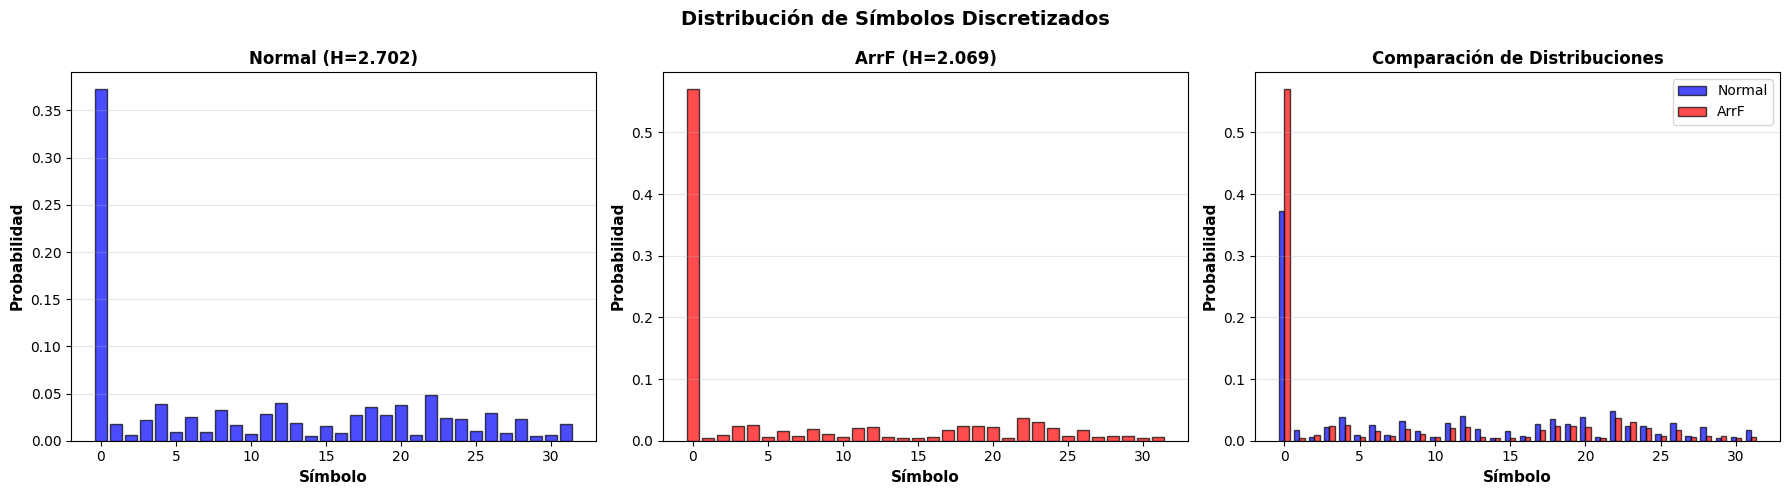

In [ ]:
# 3. Análisis de complejidad - Entropía de símbolos discretizados
windows_arrF = preprocessor.create_windows(X_arrF_padded)
discrete_arrF = preprocessor.discretize_windows(windows_arrF)

# Histogramas de símbolos
hist_normal = np.bincount(discrete_train.flatten(), minlength=VOCAB_SIZE)
hist_arrF = np.bincount(discrete_arrF.flatten(), minlength=VOCAB_SIZE)

# Normalizar para obtener probabilidades
prob_normal = hist_normal / hist_normal.sum()
prob_arrF = hist_arrF / hist_arrF.sum()

# Calcular entropías
entropy_normal = entropy(prob_normal)
entropy_arrF = entropy(prob_arrF)

print(f"\n{'='*70}")
print("ANÁLISIS DE COMPLEJIDAD (Entropía de Shannon)")
print(f"{'='*70}")
print(f"  Entropía Normal: {entropy_normal:.4f} bits")
print(f"  Entropía ArrF:   {entropy_arrF:.4f} bits")
print(f"  Diferencia:      {abs(entropy_normal - entropy_arrF):.4f} bits")

if entropy_arrF < entropy_normal:
    print(f"\n  ✓ ArrF tiene MENOR entropía → Más predecible")
    print(f"    Las señales ArrF tienen patrones más repetitivos/regulares")
else:
    print(f"\n  ✗ ArrF tiene MAYOR entropía → Menos predecible")

# Visualizar distribuciones de símbolos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Normal
axes[0].bar(range(VOCAB_SIZE), prob_normal, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
axes[0].set_title(f'Normal (H={entropy_normal:.3f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# ArrF
axes[1].bar(range(VOCAB_SIZE), prob_arrF, alpha=0.7, color='red', edgecolor='black')
axes[1].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
axes[1].set_title(f'ArrF (H={entropy_arrF:.3f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Comparación directa
x_pos = np.arange(VOCAB_SIZE)
width = 0.35
axes[2].bar(x_pos - width/2, prob_normal, width, alpha=0.7, color='blue', 
            label='Normal', edgecolor='black')
axes[2].bar(x_pos + width/2, prob_arrF, width, alpha=0.7, color='red', 
            label='ArrF', edgecolor='black')
axes[2].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
axes[2].set_title('Comparación de Distribuciones', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Distribución de Símbolos Discretizados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


DIVERGENCIA KULLBACK-LEIBLER
  KL(Normal || ArrF): 0.1220
  KL(ArrF || Normal): 0.1073
  KL Simétrica:       0.1147

  ✓ Baja divergencia KL → Distribuciones muy similares
    El modelo puede confundir ArrF con Normal

Similitud Coseno entre distribuciones: 0.9821
Overlap (Bhattacharyya): 0.7892


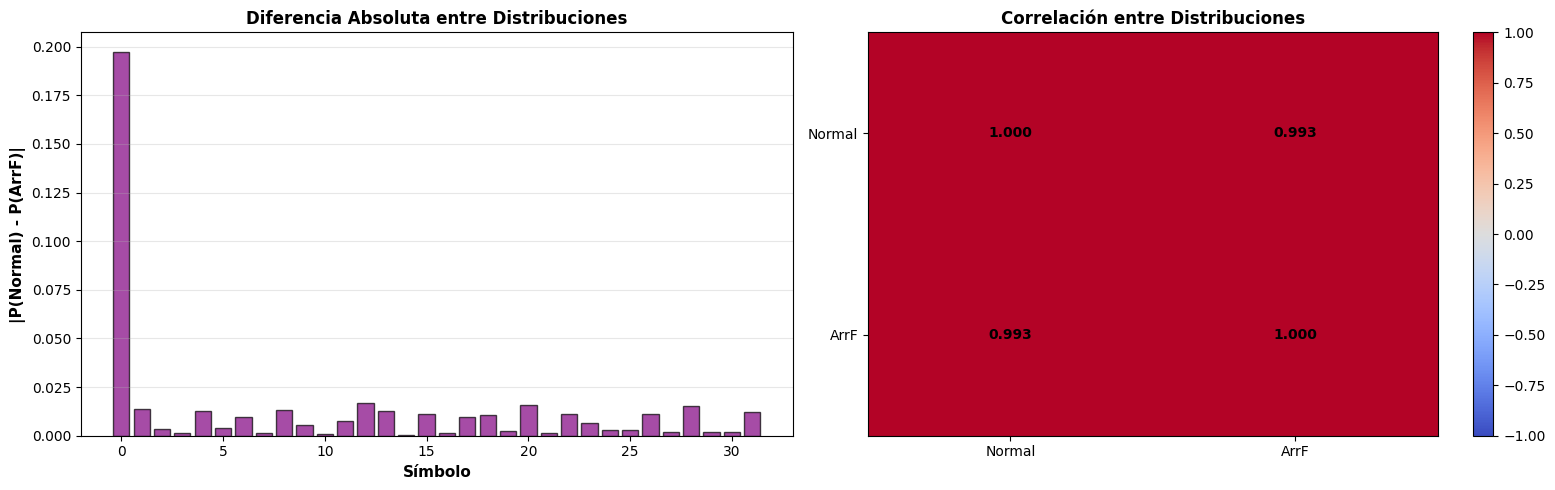

In [ ]:
# 4. Divergencia KL y similitud entre distribuciones
epsilon = 1e-10
prob_normal_safe = prob_normal + epsilon
prob_arrF_safe = prob_arrF + epsilon

kl_normal_to_arrF = np.sum(kl_div(prob_normal_safe, prob_arrF_safe))
kl_arrF_to_normal = np.sum(kl_div(prob_arrF_safe, prob_normal_safe))

print(f"\n{'='*70}")
print("DIVERGENCIA KULLBACK-LEIBLER")
print(f"{'='*70}")
print(f"  KL(Normal || ArrF): {kl_normal_to_arrF:.4f}")
print(f"  KL(ArrF || Normal): {kl_arrF_to_normal:.4f}")
print(f"  KL Simétrica:       {(kl_normal_to_arrF + kl_arrF_to_normal)/2:.4f}")

if kl_arrF_to_normal < 0.5:
    print(f"\n  ✓ Baja divergencia KL → Distribuciones muy similares")
    print(f"    El modelo puede confundir ArrF con Normal")

# Similitud de coseno entre distribuciones
cos_sim = np.dot(prob_normal, prob_arrF) / (np.linalg.norm(prob_normal) * np.linalg.norm(prob_arrF))
print(f"\nSimilitud Coseno entre distribuciones: {cos_sim:.4f}")

# Overlap de las distribuciones
overlap = np.sum(np.minimum(prob_normal, prob_arrF))
print(f"Overlap (Bhattacharyya): {overlap:.4f}")

# Visualización de diferencias
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Diferencia absoluta
diff_abs = np.abs(prob_normal - prob_arrF)
axes[0].bar(range(VOCAB_SIZE), diff_abs, alpha=0.7, color='purple', edgecolor='black')
axes[0].set_xlabel('Símbolo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('|P(Normal) - P(ArrF)|', fontsize=11, fontweight='bold')
axes[0].set_title('Diferencia Absoluta entre Distribuciones', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Heatmap de correlación
correlation_matrix = np.corrcoef([prob_normal, prob_arrF])
im = axes[1].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Normal', 'ArrF'])
axes[1].set_yticklabels(['Normal', 'ArrF'])
axes[1].set_title('Correlación entre Distribuciones', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1])

for i in range(2):
    for j in range(2):
        text = axes[1].text(j, i, f'{correlation_matrix[i, j]:.3f}',
                           ha="center", va="center", color="black", fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#basicament ArrF esta molt poc representada i te una distr semblant per aixo tendeix a no distinguirlos 